In [7]:
import numpy as np
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression
import pandas as pd
import seaborn as sns

In [8]:
games = pd.read_csv('C:\\Users\\rekha\\Desktop\\Data analysis\\Sql\\best_selling_video_games.csv')

In [9]:
games

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1
5,6,PUBG: Battlegrounds,Multi-platform,PUBG Studios,Krafton,NaN,2017,75,PUBG Universe,1
6,7,Terraria,Multi-platform,Re-Logic,Re-Logic/505 Games,NaN,2011,64,NaN,1
7,8,The Witcher 3: Wild Hunt,Multi-platform,CD Projekt Red,CD Projekt,NaN,2015,60,The Witcher,1
8,9,Super Mario Bros.[d],Multi-platform,Nintendo R&D4,Nintendo,NaN,1985,58,Super Mario,1
9,10,Human: Fall Flat,Multi-platform,No Brakes Games,Curve Digital,NaN,2016,55,NaN,1


In [10]:
# 2️⃣ Check basic info
print("Before Cleaning:\n")
print(games.info())
print("\nMissing Values:\n")
print(games.isnull().sum())

# --------------------------------------------------
# 3️⃣ Clean Release Year (remove brackets like 2011[b])
games['Releaseyear'] = games['Releaseyear'].str.extract('(\d{4})')
games['Releaseyear'] = pd.to_numeric(games['Releaseyear'], errors='coerce')

# --------------------------------------------------
# 4️⃣ Clean Sales Column (convert to numeric)
games['Sales(millions)'] = pd.to_numeric(games['Sales(millions)'], errors='coerce')

# --------------------------------------------------
# 5️⃣ Clean Rank Column
games['Rank'] = pd.to_numeric(games['Rank'], errors='coerce')

# --------------------------------------------------
# 6️⃣ Drop unnecessary column (Ref. has many null values)
if 'Ref.' in games.columns:
    games.drop(columns=['Ref.'], inplace=True)

# --------------------------------------------------
# 7️⃣ Handle Missing Values

# Fill missing Publisher with "Unknown"
games['Publisher(s)'] = games['Publisher(s)'].fillna("Unknown")

# Fill missing Series with "Standalone"
games['Series'] = games['Series'].fillna("Standalone")

# Drop rows where Sales is missing
games = games.dropna(subset=['Sales(millions)'])

# --------------------------------------------------
# 8️⃣ Final Check
print("\nAfter Cleaning:\n")
print(games.info())
print("\nMissing Values After Cleaning:\n")
print(games.isnull().sum())

# Save cleaned file (optional)
games.to_csv("cleaned_best_selling_games.csv", index=False)

print("\n✅ Data Cleaning Completed Successfully!")

Before Cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Rank             50 non-null     object
 1   Title            50 non-null     object
 2   Platform(s)      50 non-null     object
 3   Developer(s)     50 non-null     object
 4   Publisher(s)     42 non-null     object
 5   Ref.             10 non-null     object
 6   Releaseyear      50 non-null     object
 7   Sales(millions)  49 non-null     object
 8   Series           45 non-null     object
 9   Table_Number     50 non-null     int64 
dtypes: int64(1), object(9)
memory usage: 4.0+ KB
None

Missing Values:

Rank                0
Title               0
Platform(s)         0
Developer(s)        0
Publisher(s)        8
Ref.               40
Releaseyear         0
Sales(millions)     1
Series              5
Table_Number        0
dtype: int64

After Cleaning:

<class 'pandas.

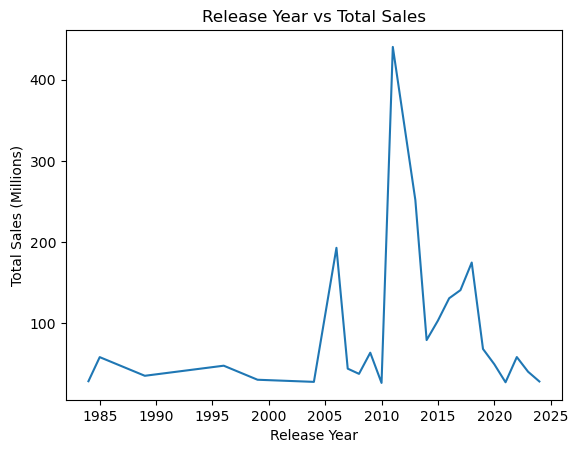

In [11]:
# Group by Release Year
year_sales = games.groupby('Releaseyear')['Sales(millions)'].sum()

plt.figure()
plt.plot(year_sales.index, year_sales.values)
plt.title("Release Year vs Total Sales")
plt.xlabel("Release Year")
plt.ylabel("Total Sales (Millions)")
plt.show()

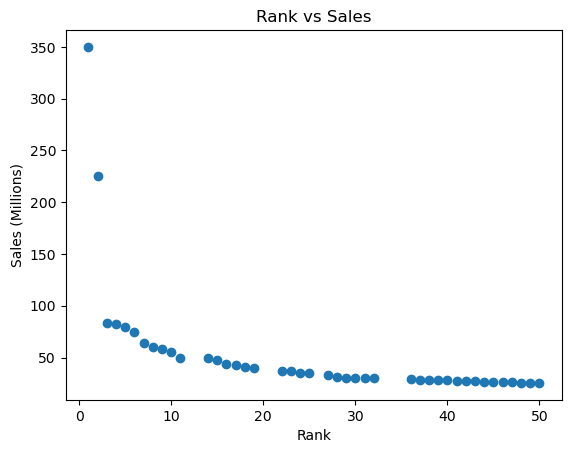

In [13]:
plt.figure()
plt.scatter(games['Rank'], games['Sales(millions)'])
plt.title("Rank vs Sales")
plt.xlabel("Rank")
plt.ylabel("Sales (Millions)")
plt.show()

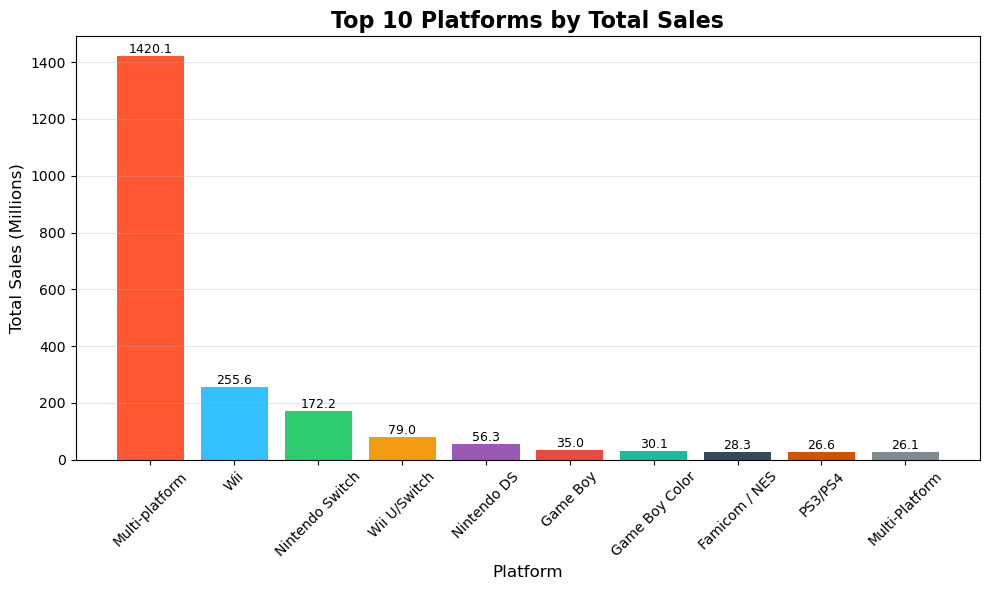

In [17]:
# Aggregate Top 10 Platforms
platform_sales = (
    games.groupby('Platform(s)')['Sales(millions)']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Create custom color list
colors = ['#FF5733', '#33C1FF', '#2ECC71', '#F39C12', 
          '#9B59B6', '#E74C3C', '#1ABC9C', '#34495E',
          '#D35400', '#7F8C8D']

plt.figure(figsize=(10,6))
bars = plt.bar(platform_sales.index, platform_sales.values, color=colors)

plt.title("Top 10 Platforms by Total Sales", fontsize=16, fontweight='bold')
plt.xlabel("Platform", fontsize=12)
plt.ylabel("Total Sales (Millions)", fontsize=12)
plt.xticks(rotation=45)

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=9)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

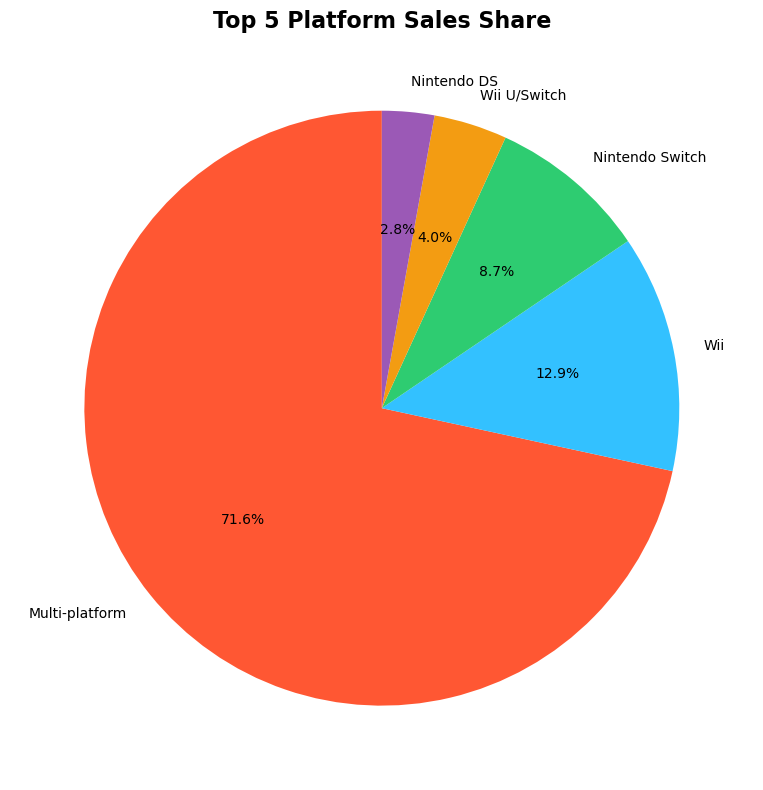

In [20]:
# Group Top 5 Platforms
platform_sales = (
    games.groupby('Platform(s)')['Sales(millions)']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

# Create Pie Chart
plt.figure(figsize=(8,8))

plt.pie(platform_sales.values,
        labels=platform_sales.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#FF5733', '#33C1FF', '#2ECC71', '#F39C12', '#9B59B6'])

plt.title("Top 5 Platform Sales Share", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

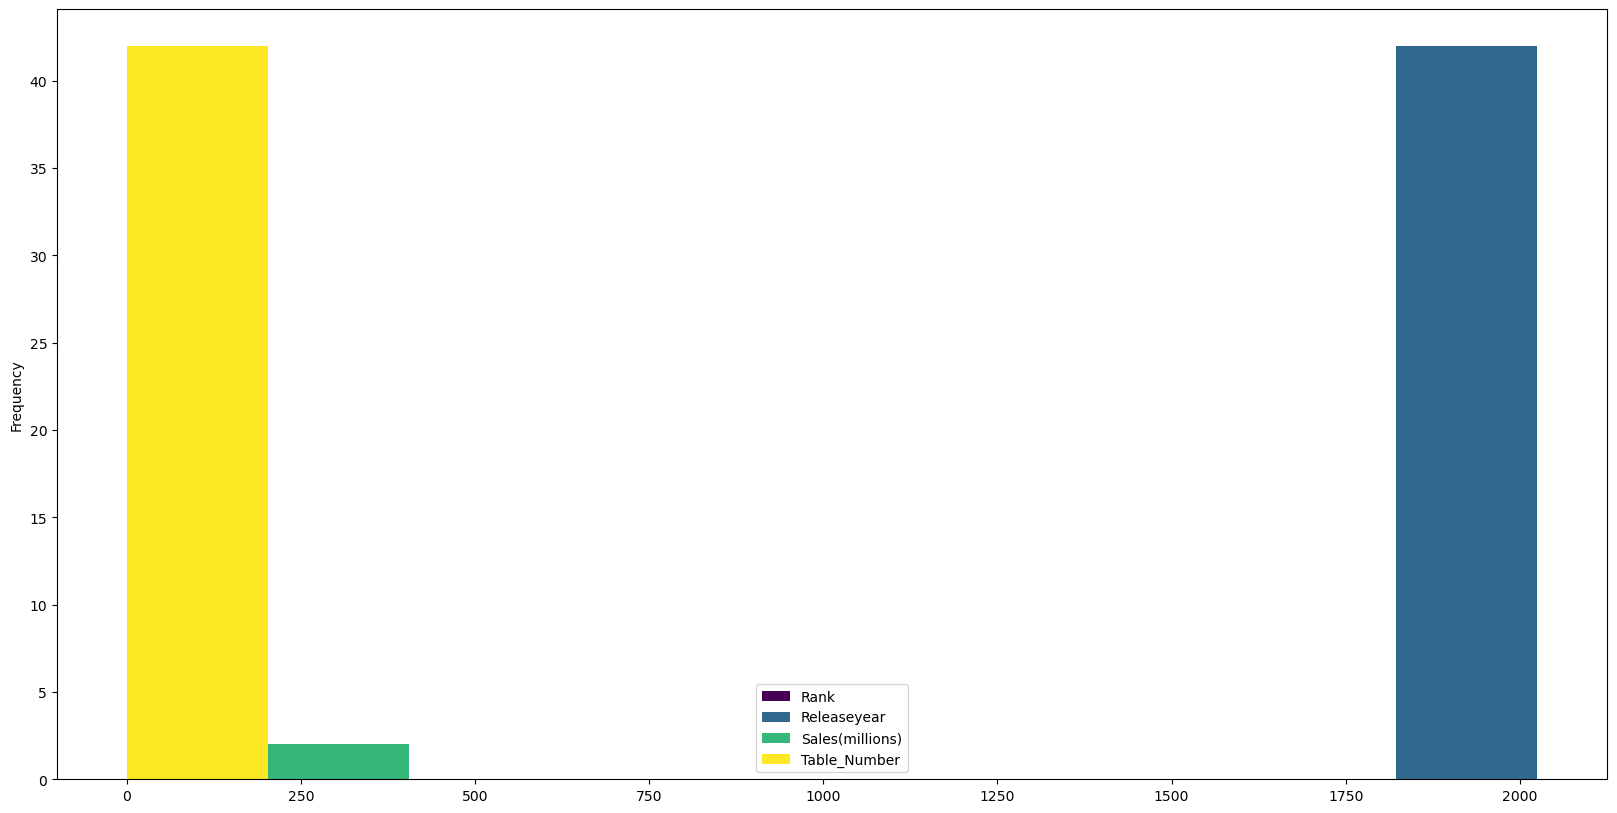

In [31]:
games.plot(kind='hist',stacked=False, figsize=(20,10),colormap='viridis')

<Axes: >

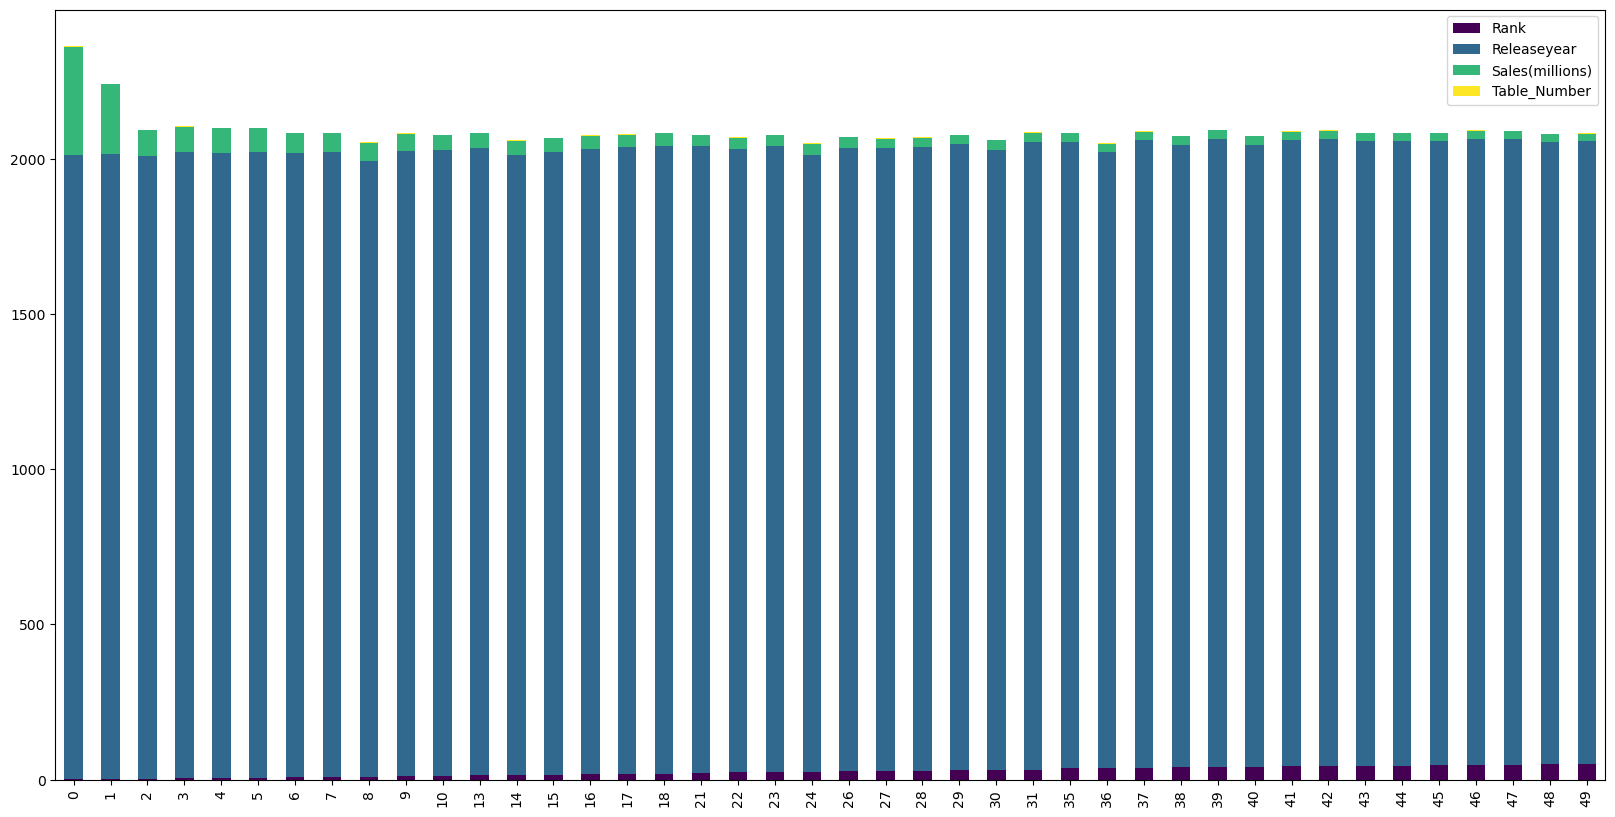

In [33]:
games.plot(kind='bar',stacked=True, figsize=(20,10),colormap='viridis')